# Implementation of Deep Learning Architectures on CIFAR-10 Dataset

In this project, different neural network architectures are implemented on the CIFAR-10 dataset and compared based on their performance.

Importing requirements first.

In [64]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt

## Dataset

We use the CIFAR-10 dataset available in torchvision datasets.
The dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class.

The mutually exclusive classes are:
- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck


Setting up train and test data.

In [77]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5, 0.5, 0.5),
                         std=(0.5, 0.5, 0.5))
])

train_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=transform
)

In [66]:

# See first training sample
image, label = train_data[0]
image, label


(tensor([[[-0.5373, -0.6627, -0.6078,  ...,  0.2392,  0.1922,  0.1608],
          [-0.8745, -1.0000, -0.8588,  ..., -0.0353, -0.0667, -0.0431],
          [-0.8039, -0.8745, -0.6157,  ..., -0.0745, -0.0588, -0.1451],
          ...,
          [ 0.6314,  0.5765,  0.5529,  ...,  0.2549, -0.5608, -0.5843],
          [ 0.4118,  0.3569,  0.4588,  ...,  0.4431, -0.2392, -0.3490],
          [ 0.3882,  0.3176,  0.4039,  ...,  0.6941,  0.1843, -0.0353]],
 
         [[-0.5137, -0.6392, -0.6235,  ...,  0.0353, -0.0196, -0.0275],
          [-0.8431, -1.0000, -0.9373,  ..., -0.3098, -0.3490, -0.3176],
          [-0.8118, -0.9451, -0.7882,  ..., -0.3412, -0.3412, -0.4275],
          ...,
          [ 0.3333,  0.2000,  0.2627,  ...,  0.0431, -0.7569, -0.7333],
          [ 0.0902, -0.0353,  0.1294,  ...,  0.1608, -0.5137, -0.5843],
          [ 0.1294,  0.0118,  0.1137,  ...,  0.4431, -0.0745, -0.2784]],
 
         [[-0.5059, -0.6471, -0.6627,  ..., -0.1529, -0.2000, -0.1922],
          [-0.8431, -1.0000,

In [67]:
image.shape

torch.Size([3, 32, 32])

The image is a vector with three elements namely the color_channels, height and width.
So, for the displayed image shape:

`[color_channel=3, height=32, width=32]`

Here, `color_channels = 3` which indicates 3 color channels for the RGB color model.
the height and width are of the same value 32 as the dataset consists of tiny square images.

In [68]:
# how many samples are there?
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(50000, 50000, 10000, 10000)

Displaying examples images from data.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7254902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.64705884..0.90588236].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5921569..0.43529415].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.9529412].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.84313726..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8509804..1.0].
Cli

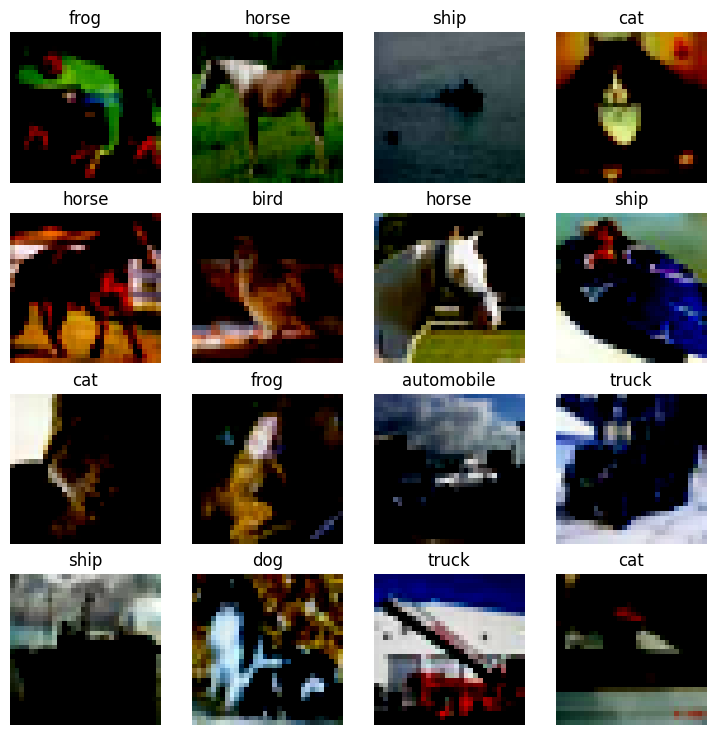

In [78]:
torch.manual_seed(42)
class_names = train_data.classes
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.permute(1, 2, 0))  # convert to HWC format for plotting
    plt.title(class_names[label])
    plt.axis(False)


### Data Preparation

Setup the batches of 32 of the data using `torch.utils.data.Dataloader`.

In [8]:
train_loader = torch.utils.data.DataLoader(train_data,
                                           batch_size=32,
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(test_data,
                                          batch_size=32,
                                          shuffle=False)

Setup up device.

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Neural Network

Implementing a simple baseline neural network for image classification. This model lacks convolutional layers and provides a reference point

In [10]:
class baseNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(), # flatten the image into a vector
            nn.Linear(32*32*3, 512), # input size is 3*32*32, output size is 512
            nn.ReLU(), # activation function
            nn.Linear(512, 10) # output size is 10, one for each class
        )

    def forward(self, x):
        return self.net(x) # forward pass through the network

## AlexNet

AlexNet is a deep convolutional neural network that introduced key innovations such as ReLU activations, dropout, and deep hierarchical feature learning.
We the implement the AlexNet model with modifications in the model. For our data, we use a kernel size of 3, stride of 1 and a padding of 1.

In [11]:

class AlexNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1), # input channels = 3, output channels = 64
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 192, kernel_size=3, padding=1), # input channels = 64, output channels = 192
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(192, 384, kernel_size=3, padding=1), # input channels = 192, output channels = 384
            nn.ReLU(),

            nn.Conv2d(384, 256, kernel_size=3, padding=1), # input channels = 384, output channels = 256
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1), # input channels = 256, output channels = 256
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1024), # input size is 256*4*4, output size is 1024
            nn.ReLU(),
            nn.Dropout(0.5), # dropout for regularization
            nn.Linear(1024, 10) # output size is 10, one for each class
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

## TinyVGG

TinyVGG is a lightweight convolutional architecture inspired by the VGG design philosophy, using small convolutional kernels and fewer layers. It focuses on simplicity and efficiency while still maintaining strong feature extraction capabilities for image classification tasks.

In [12]:
class TinyVGG(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

## Loss Function, Optimizer & Metrics

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer_choice = torch.optim.Adam

## Training and Evaluation Loops

In [14]:
import time

def train_and_eval(model, optimizer, epochs):
    model.to(device)
    train_accs, test_accs = [], []
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        train_accs.append(train_acc)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        test_acc = correct / total
        test_accs.append(test_acc)

        print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}")

    training_time = time.time() - start_time
    return train_accs, test_accs, training_time

### Model Training

In [15]:
nn_model = baseNN()
optimizer = torch.optim.Adam(nn_model.parameters(), lr=0.001)
nn_results = train_and_eval(nn_model, optimizer, epochs=10)

Epoch 1: Train Acc=0.4099, Test Acc=0.4631
Epoch 2: Train Acc=0.4768, Test Acc=0.4674
Epoch 3: Train Acc=0.5066, Test Acc=0.4854
Epoch 4: Train Acc=0.5335, Test Acc=0.4888
Epoch 5: Train Acc=0.5542, Test Acc=0.4899
Epoch 6: Train Acc=0.5752, Test Acc=0.5065
Epoch 7: Train Acc=0.5905, Test Acc=0.4908
Epoch 8: Train Acc=0.6056, Test Acc=0.5019
Epoch 9: Train Acc=0.6228, Test Acc=0.4981
Epoch 10: Train Acc=0.6375, Test Acc=0.5118


In [16]:
alexnet_model = AlexNet()
optimizer = torch.optim.Adam(alexnet_model.parameters(), lr=0.001)
alexnet_results = train_and_eval(alexnet_model, optimizer, epochs=10)

Epoch 1: Train Acc=0.4554, Test Acc=0.6091
Epoch 2: Train Acc=0.6382, Test Acc=0.6734
Epoch 3: Train Acc=0.7151, Test Acc=0.7162
Epoch 4: Train Acc=0.7564, Test Acc=0.7379
Epoch 5: Train Acc=0.7886, Test Acc=0.7527
Epoch 6: Train Acc=0.8120, Test Acc=0.7512
Epoch 7: Train Acc=0.8324, Test Acc=0.7618
Epoch 8: Train Acc=0.8502, Test Acc=0.7573
Epoch 9: Train Acc=0.8625, Test Acc=0.7623
Epoch 10: Train Acc=0.8734, Test Acc=0.7666


In [17]:
tinyvgg_model = TinyVGG()
optimizer = torch.optim.Adam(tinyvgg_model.parameters(), lr=0.001)
tinyvgg_results = train_and_eval(tinyvgg_model, optimizer, epochs=10)

Epoch 1: Train Acc=0.5246, Test Acc=0.6314
Epoch 2: Train Acc=0.7041, Test Acc=0.7247
Epoch 3: Train Acc=0.7717, Test Acc=0.7416
Epoch 4: Train Acc=0.8209, Test Acc=0.7404
Epoch 5: Train Acc=0.8638, Test Acc=0.7506
Epoch 6: Train Acc=0.8987, Test Acc=0.7395
Epoch 7: Train Acc=0.9274, Test Acc=0.7509
Epoch 8: Train Acc=0.9473, Test Acc=0.7311
Epoch 9: Train Acc=0.9526, Test Acc=0.7407
Epoch 10: Train Acc=0.9609, Test Acc=0.7420


In [18]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

nn_params = count_parameters(nn_model)
alexnet_params = count_parameters(alexnet_model)
tinyvgg_params = count_parameters(tinyvgg_model)

print(f"BaseNN Parameters: {nn_params} \nAlexNet Parameters: {alexnet_params} \nTinyVGG Parameters: {tinyvgg_params}")

BaseNN Parameters: 1578506 
AlexNet Parameters: 6457162 
TinyVGG Parameters: 1116970


## Evaluation and Comparision

The models AlexNet and TinyVGG were evaluated using training accuracy, test accuracy, training time, and model complexity (number of trainable parameters).

The AlexNet reached a final training accuracy of 87.34% and a test accuracy of 76.66% in 4 minutes of training. The model used approximately 6.46 million parameters.

The TinyVGG model achieved a very high training accuracy of 96.09%, but its test accuracy was 75.09%, slightly lower than AlexNet. Training time was around 3 minutes, and the model used only 1.12 million parameters.

Overall, AlexNet achieved the higher test accuracy while requiring more computational power and training time. TinyVGG on the other hand, provided a better balance between accuracy, efficiency, and training speed.

## Discussion

The results of the project reflect the importance of convolutional neural networks for image classification tasks. The Base NN model, despite having a comparable number of parameters to TinyVGG, performed poorly due to its limited ability.

AlexNet introduced several major improvements over earlier neural network architectures, including the use of deep convolutional layers, ReLU activation functions, and dropout for regularization. These innovations enabled faster training, reduced vanishing gradient issues, and significantly improved feature learning and generalization.

AlexNet showed substantial improvements over the baseline due to its deep convolutional architecture, ReLU activations, and pooling layers. Its provided strong test accuracy, but the large number of parameters resulted in longer training time and higher computational cost.

TinyVGG showed rapid convergence and very high training accuracy, indicating strong learning capacity. The noticeable gap between training and test accuracy suggests mild overfitting. TinyVGG’s performance is still impressive given its significantly smaller parameter count and faster training time compared to AlexNet.


## Conclusion

In this experiment, three neural network architectures were implemented and evaluated on the CIFAR-10 dataset. The baseline model, with no convolution layers, performed the worst. AlexNet achieved the highest test accuracy, demonstrating the effectiveness of deep convolutional architectures for complex visual recognition problems. TinyVGG provided an efficient alternative, offering comparable performance with fewer parameters and reduced training time.

Thus, we were able to implement different neural network models for an image classification task, evaluating and comparing them in terms of training time, accuracy and parameters.

## References
CIFAR-10 Dataset:
- [Learning Multiple Layers of Features from Tiny Images](https://www.cs.toronto.edu/~kriz/learning-features-2009-TR.pdf), Alex Krizhevsky, 2009.